# STAC and cloud-native Sentinel-2

In [89]:
import pystac_client
import planetary_computer
import numpy as np
import matplotlib.pyplot as plt
from odc.stac import load

## Searching Planetary Computer for Sentinel 2 data

In [90]:
# Reads the root catalogue of the planetary computer STAC (SpatioTemporal Asset Catalogue), 
# then signs the relevant URLs with an access token to enable reading

planetary_computer_catalog = pystac_client.Client.open(
'https://planetarycomputer.microsoft.com/api/stac/v1',
modifier=planetary_computer.sign_inplace)




bbox = [-104.48, 68.97, -103.59, 69.23]         # small Arctic bounding box (min lon, min lat, max lon, max lat), Lena delta region (Siberia)

# Searches the Planetary Computer catalogue based on the specified filters, then accesses the scenes (using .items()) and creates a list of these.

Victoria_Island_items = list(planetary_computer_catalog.search(
collections=['sentinel-2-l2a'],
bbox=bbox,
datetime='2022-08-01/2022-08-31',     # Sets date range from 00:00 on the first date to 23:59 on the last (if just months, goes from first to last day)
query={'eo:cloud_cover': {'lt': 20}}).items())   # Filters by scenes that have less than 20% cloud cover

print(f'found {len(Victoria_Island_items)} scenes from Planetary Computer')  

Victoria_Island_items[6]     # Prints metadata for the first found scene, including satellite information

found 12 scenes from Planetary Computer


<Item id=S2B_MSIL2A_20220823T190919_R056_T13WES_20240704T135759>

## Searching for Sentinel 2 data using AWS Earth Search

An alternative way to search for satellite data that eliminates the need for signing. 

Finds fewer scenes for the same search criteria.

In [91]:
# Opens the root catalogue, no need for signing 

cat_aws = pystac_client.Client.open('https://earth-search.aws.element84.com/v1')

# Searches for sentinel 2 data with the same filters as before, this time using the AWS Earth Search catalogue

Victoria_Island_items_aws = list(cat_aws.search(
collections = ['sentinel-2-l2a'],
bbox = bbox,
datetime = '2022-02/2022-02',
query = {'eo:cloud_cover': {'lt': 20}},
).items())

print(len(Victoria_Island_items_aws), 'scenes from Earth Search')

Victoria_Island_items_aws[1]

3 scenes from Earth Search


<Item id=S2A_13WES_20220226_0_L2A>

## Using odc-stac to load the data into xarray

Uses dask to chunk the data and load these in parallel to improve efficiency. 

The different bands are specified here (these aliases vary based on the catalogue used). 

SCL aka scene classification layer assigns a value to each pixel based on the surface type.

In [92]:
# Loads the scenes from AWS Earth Search into an xarray dataset using odc.stac's load function.

# By default it groups the items by time (equal timestamps lie in the same plane) and anchors the grid
# by aligning the pixel edges with 0,0 by default, can change this (see 'load' function info)

Victoria_Island_data = load(
Victoria_Island_items,
bands = ['red', 'green', 'blue', 'nir', 'swir16', 'rededge', 'SCL'],  # red, green, blue, NIR, and SWIR filters, as well as SCL layer
bbox = bbox,
chunks = {'x': 1024, 'y': 1024}, # loads data in 1,204 x 1,024 pixel chunks in parallel using dask
resolution = 10)             # Converts the resolution of the data (via interpolation or averaging, 
                             # depending on if the resolution is higher or lower than the original data)
                             # Note: Interpolation can produce some odd results depending on the method used e.g. 'blocky' images and rough edges.

#Lena_Delta_data['x']

type(Victoria_Island_data)

xarray.core.dataset.Dataset

## Masking cloud using SCL layer and creating an RGB true colour composite

Uses the scence classification layer to apply a cloud mask and then creates a true colour composite.

In [93]:
# Assigns 'True' to all pixels that have an SCL value of 4, 5, 6, 7 or 11 (vegetation, bare soil, or water)
# Pixels identified as other types i.e. clouds/cloud shadows are masked out (assigned 'False')

good = Victoria_Island_data['SCL'].isin([4, 5, 6, 7, 11])   
#print('Done')

# Extracts the rgb (true colour) values for the pixels that match the specified scl values (i.e. applies the cloud mask)
# Passing a list of strings (double brackets) tells xarray to create a subset. It keeps this as a dataset object,
# but discards all other variables except the ones you listed (rgb).

rgb = Victoria_Island_data[['red', 'green', 'blue']].where(good)
print('Done')

# Downsample by taking an average of every 5x5 pixel block (increases runtime)

#coarse_composite = rgb.coarsen(x=5, y=5, boundary='trim').mean()

# Collapses the time dimension down by taking the median of each red, green, and blue value in the 'rgb' subset.
# This also eliminates any light cloud, shadow edges or other artefcats that the mask didn't pick up, as these 
# would be have extreme values (high for cloud, low for shadow).

Victoria_Island_composite = rgb.median('time')
print('Done')
rgb

Done
Done


<xarray.Dataset> Size: 891MB
Dimensions:      (time: 7, y: 2956, x: 3590)
Coordinates:
  * time         (time) datetime64[us] 56B 2022-08-02T18:49:31.024000 ... 202...
  * y            (y) float64 24kB 7.681e+06 7.681e+06 ... 7.651e+06 7.651e+06
  * x            (x) float64 29kB 5.206e+05 5.206e+05 ... 5.565e+05 5.565e+05
    spatial_ref  int32 4B 32613
Data variables:
    red          (time, y, x) float32 297MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    green        (time, y, x) float32 297MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    blue         (time, y, x) float32 297MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>

## Plots the true colour composite using xarray

Converts to an array for plotting, reduces, clips, and plots.

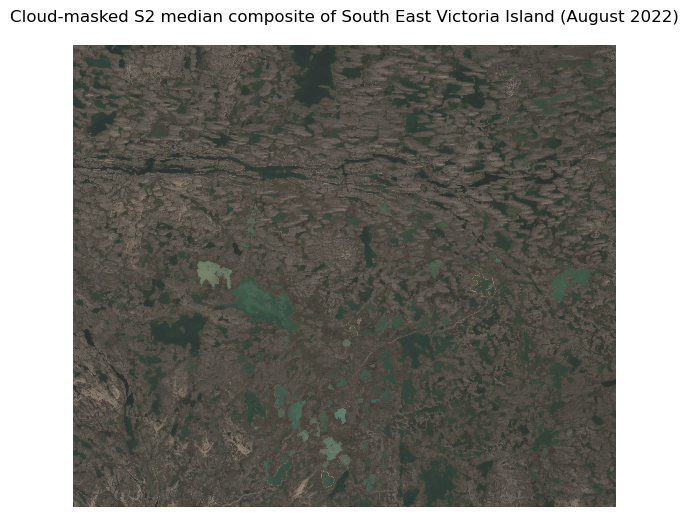

In [94]:
# Converts the dataset to a DataArray, divides to reduce the raw reflectance values, then clips extreme values to 1.
# This conversion also adds the 'variable' dimension i.e. the rgb values.

Victoria_Island_array = (Victoria_Island_composite.to_array() / 6000).clip(0, 1)

# Plots directly using xarray's wrapper, by using plot.imshow() and defining the variable (third dimension) as 'rgb'.

plt.figure(figsize=(7, 6))
Victoria_Island_array.plot.imshow(rgb='variable')

plt.axis('off')
plt.title('Cloud-masked S2 median composite of South East Victoria Island (August 2022)')
plt.show()

## Calculating and plotting NDWI

Calculates modified NDWI using Green and SWIR to account for false positives (shallow lakes showing up as higher/deeper values), still showing shallow lakes (lighter in rgb image) as higher values...

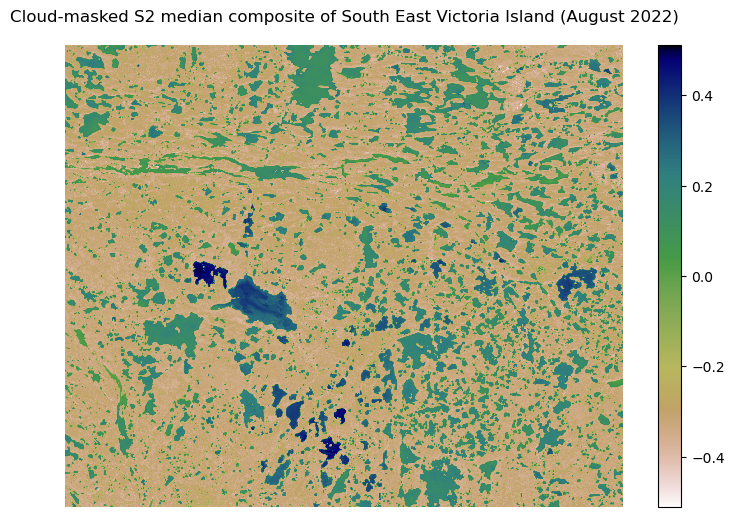

In [96]:
# Extracts the NIR, SWIR and green bands from the Victoria_Island dataset object, this returns xarray data arrays
# (due to passing values in single brackets).  


Near_IR = Victoria_Island_data['nir'].where(good)
Green = rgb['green'].where(good)
Short_wave_IR = Victoria_Island_data['swir16'].where(good)
Red_edge = Victoria_Island_data['rededge']

# Then calculates NDWI, Red_Edge_NDWI and MNDWI (Modified Normalised Difference Water Index), plots MNDWI. 
# Does this as NDWI resulted in false positives, likely due to algae/sediment in shallow lakes reflecting more green light.

#Normalised_Difference_Water_Index = (Green - Near_IR)/(Green + Near_IR)

Modified_Normalised_Difference_Water_Index = (Green - Short_wave_IR)/(Green + Short_wave_IR)

Red_edge_NDWI = (Green - Red_edge)/(Green + Red_edge)

Victoria_Island_MNDWI = Modified_Normalised_Difference_Water_Index.median('time')

Victoria_Island_Red_edge_NDWI = Red_edge_NDWI.median('time')

plt.figure(figsize=(9, 6))
Victoria_Island_MNDWI.plot.imshow(cmap='gist_earth_r')
plt.axis('off')
plt.title('Cloud-masked S2 median composite of South East Victoria Island (August 2022)')
plt.show()